#importing libraries

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,classification_report
import os
from dotenv import load_dotenv

load datasets

In [2]:

load_dotenv()

print(os.getenv("PROJECT_ROOT"))
print(os.getenv("DATASET"))

C:\Users\swath\Desktop\Projects_MLDL\AI-Impact-on-Jobs-and-Layoff-Risk\AI-Impact-on-Jobs-and-Layoff-Risk-Prediction
C:\Users\swath\Desktop\Projects_MLDL\AI-Impact-on-Jobs-and-Layoff-Risk\AI-Impact-on-Jobs-and-Layoff-Risk-Prediction/dataset/ai-impact-jobs-layoff-risk-dataset.csv


In [3]:
df=pd.read_csv(os.getenv("DATASET"))

In [7]:
pd.set_option("display.max_columns", None)

In [8]:
#first 5 rows

print(df.head())

   Age Education_Level  Years_of_Experience       Industry  \
0   59        Master's                    6        Finance   
1   44        Master's                   14  Manufacturing   
2   36      Bachelor's                    7         Retail   
3   27      Bachelor's                    6        Finance   
4   49     High School                   12        Finance   

                Job_Role Company_Size Job_Level  Routine_Task_Percentage  \
0             Accountant       Medium     Entry                       84   
1  Production Supervisor        Small     Entry                       30   
2          Store Manager       Medium    Senior                       12   
3                Auditor        Large     Entry                       90   
4                Auditor        Small     Entry                       49   

   Creativity_Requirement  Human_Interaction_Level AI_Adoption_Level  \
0                      21                       94            Medium   
1                      84 

In [9]:
print("dataset shape",df.shape)
print("dataset info",df.info())

dataset shape (20000, 16)
<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Age                         20000 non-null  int64
 1   Education_Level             20000 non-null  str  
 2   Years_of_Experience         20000 non-null  int64
 3   Industry                    20000 non-null  str  
 4   Job_Role                    20000 non-null  str  
 5   Company_Size                20000 non-null  str  
 6   Job_Level                   20000 non-null  str  
 7   Routine_Task_Percentage     20000 non-null  int64
 8   Creativity_Requirement      20000 non-null  int64
 9   Human_Interaction_Level     20000 non-null  int64
 10  AI_Adoption_Level           20000 non-null  str  
 11  Number_of_AI_Tools_Used     20000 non-null  int64
 12  AI_Usage_Hours_Per_Week     20000 non-null  int64
 13  Tasks_Automated_Percentage  20000 non-null  in

In [10]:
print("Checking missing values")
print(df.isnull().sum())

Checking missing values
Age                           0
Education_Level               0
Years_of_Experience           0
Industry                      0
Job_Role                      0
Company_Size                  0
Job_Level                     0
Routine_Task_Percentage       0
Creativity_Requirement        0
Human_Interaction_Level       0
AI_Adoption_Level             0
Number_of_AI_Tools_Used       0
AI_Usage_Hours_Per_Week       0
Tasks_Automated_Percentage    0
AI_Training_Hours             0
Layoff_Risk                   0
dtype: int64


we have no any null values

data cleaning and EDA

In [11]:
#categorical columns and numeric columns list
cat_col=df.select_dtypes(exclude=np.number).columns.to_list()
num_col=df.select_dtypes(include=np.number).columns.to_list()
print("categorical columns: ",cat_col,"len",len(cat_col))
print("\n numerical columns",num_col,"len",len(num_col))

categorical columns:  ['Education_Level', 'Industry', 'Job_Role', 'Company_Size', 'Job_Level', 'AI_Adoption_Level', 'Layoff_Risk'] len 7

 numerical columns ['Age', 'Years_of_Experience', 'Routine_Task_Percentage', 'Creativity_Requirement', 'Human_Interaction_Level', 'Number_of_AI_Tools_Used', 'AI_Usage_Hours_Per_Week', 'Tasks_Automated_Percentage', 'AI_Training_Hours'] len 9


In [20]:
#let's see the values counts of categorical columns

for i in cat_col:
    print("Number of values and it's count in ",i)
    print("\n",df[i].value_counts())
    print("*"*30)
    


Number of values and it's count in  Education_Level

 Education_Level
Bachelor's     9967
Master's       5426
High School    3558
PhD            1049
Name: count, dtype: int64
******************************
Number of values and it's count in  Industry

 Industry
Telecom          2582
Healthcare       2561
Finance          2513
Logistics        2488
IT               2483
Retail           2467
Manufacturing    2457
Education        2449
Name: count, dtype: int64
******************************
Number of values and it's count in  Job_Role

 Job_Role
Nurse                    900
Medical Assistant        889
Financial Analyst        879
Support Specialist       873
Network Engineer         862
Operator                 858
Inventory Analyst        857
Supply Chain Analyst     857
Data Analyst             849
Operations Analyst       847
Warehouse Manager        843
Software Engineer        829
Accountant               821
Academic Coordinator     819
Research Assistant       818
Auditor      

In [23]:
for i in cat_col:
    print(i)
    print(df[i].nunique(),"\n")

Education_Level
4 

Industry
8 

Job_Role
24 

Company_Size
3 

Job_Level
3 

AI_Adoption_Level
3 

Layoff_Risk
3 



In [24]:
print(df["Industry"].unique())

<ArrowStringArray>
[      'Finance', 'Manufacturing',        'Retail',       'Telecom',
            'IT',     'Logistics',    'Healthcare',     'Education']
Length: 8, dtype: str


In [26]:
print(df["Job_Role"].unique())

<ArrowStringArray>
[           'Accountant', 'Production Supervisor',         'Store Manager',
               'Auditor',      'Network Engineer',     'Software Engineer',
           'ML Engineer',     'Inventory Analyst',            'Dispatcher',
        'Health Analyst',    'Support Specialist',       'Sales Associate',
  'Academic Coordinator',     'Financial Analyst',              'Operator',
    'Research Assistant',      'Quality Engineer',               'Teacher',
     'Warehouse Manager',  'Supply Chain Analyst',    'Operations Analyst',
     'Medical Assistant',                 'Nurse',          'Data Analyst']
Length: 24, dtype: str


<Axes: >

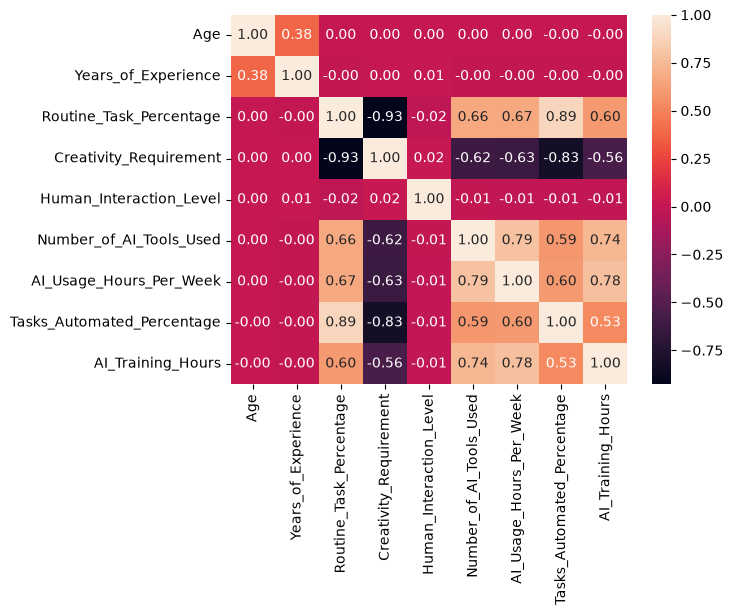

In [30]:
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt=".2f")

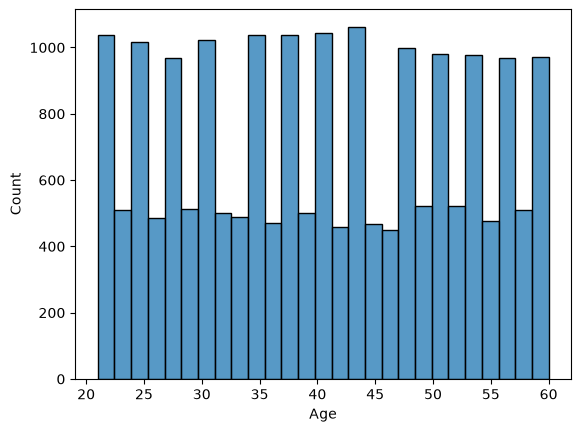

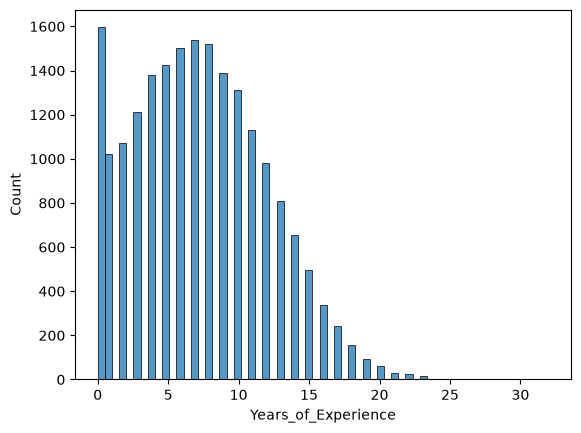

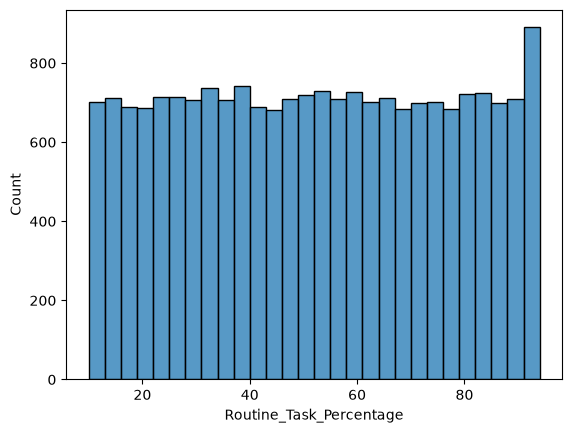

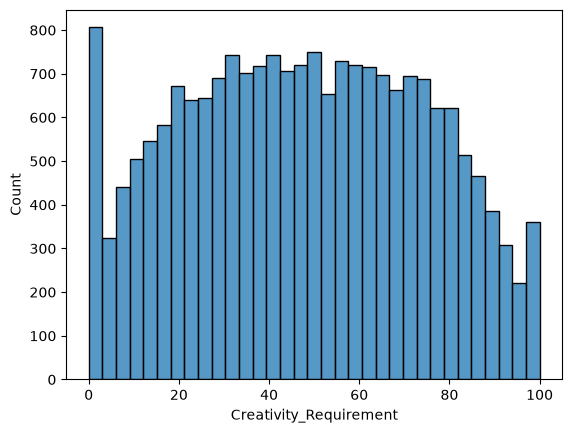

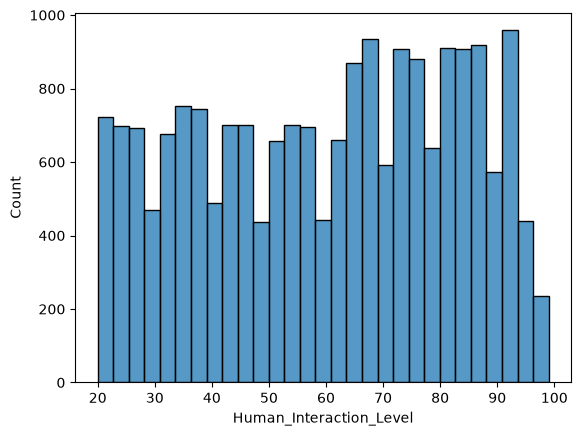

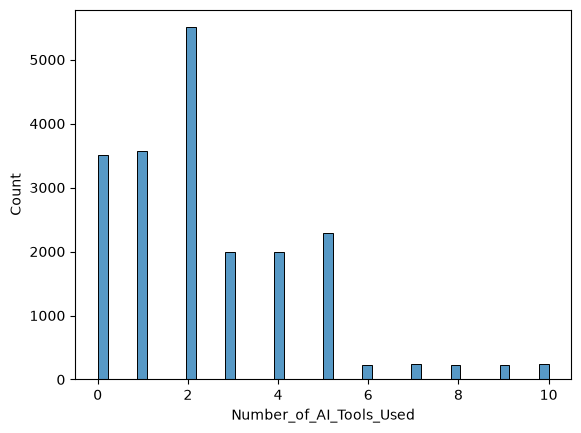

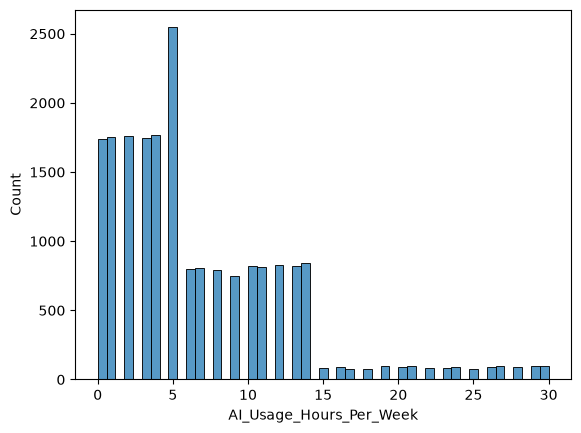

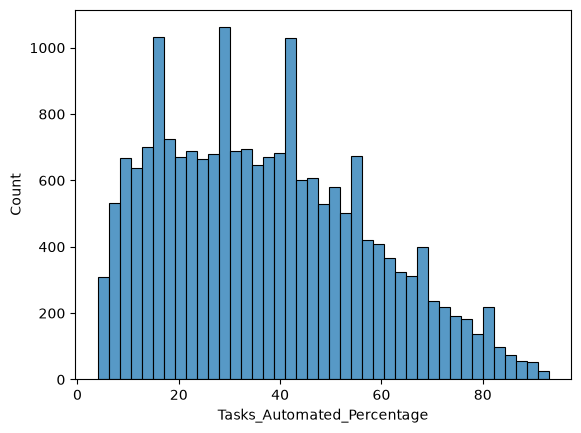

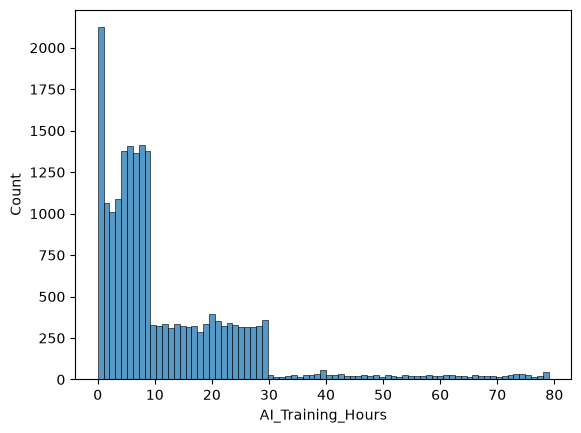

In [32]:
for i in num_col:
    sns.histplot(df[i])
    plt.show()

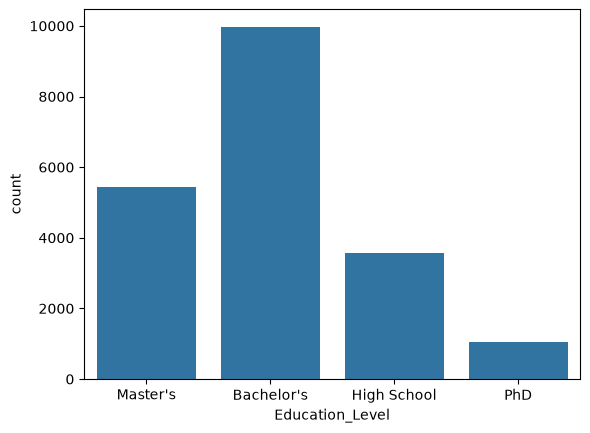

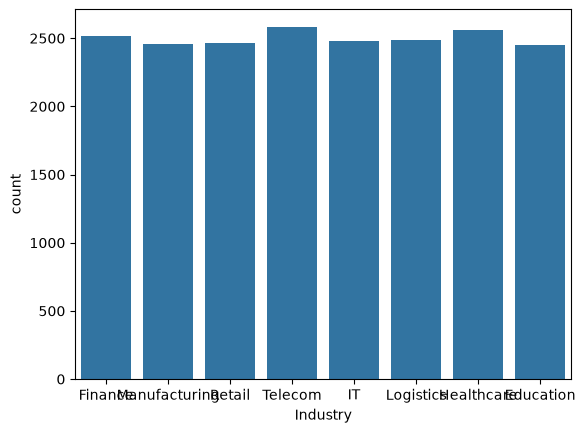

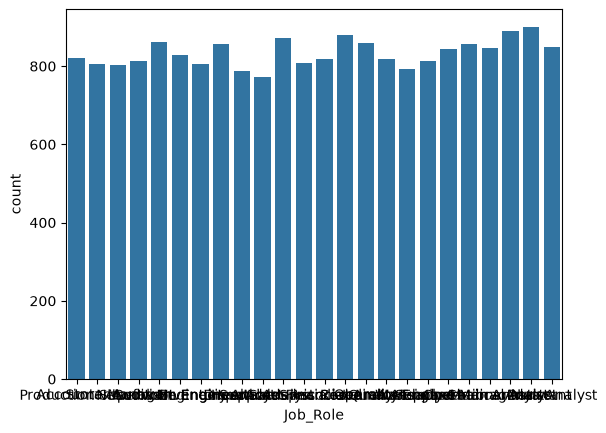

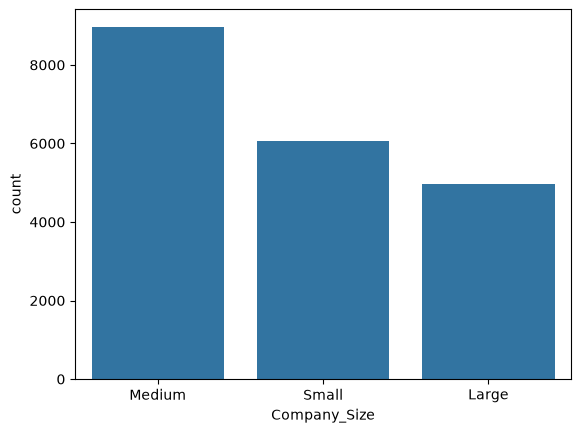

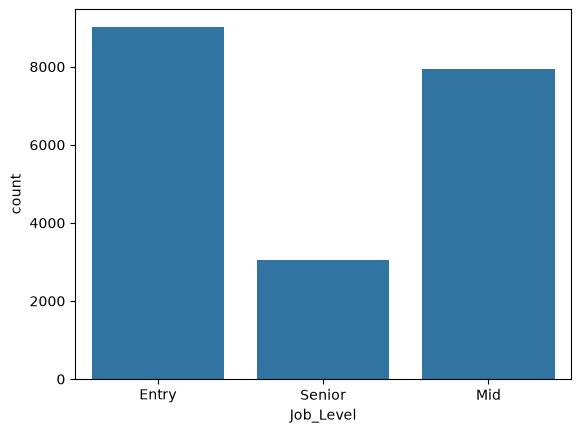

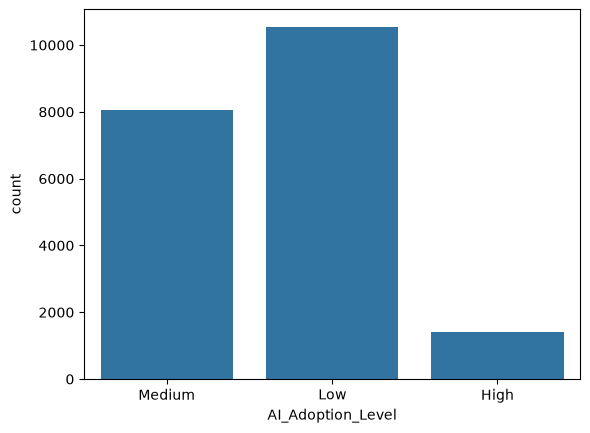

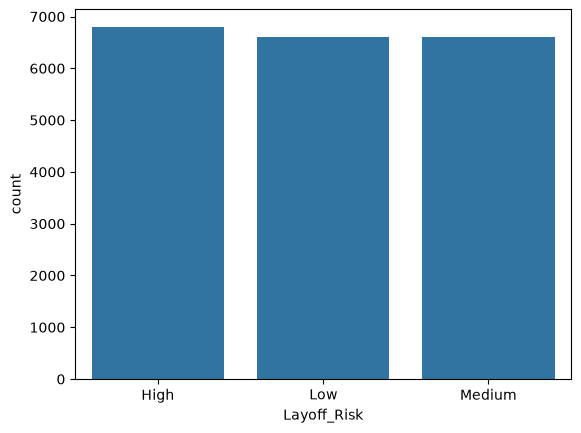

In [34]:
for i in cat_col:
    sns.countplot(x=df[i])
    plt.show()

In [35]:
for i in cat_col:
    print(i,df[i].unique())
    print("\n")

Education_Level <ArrowStringArray>
['Master's', 'Bachelor's', 'High School', 'PhD']
Length: 4, dtype: str


Industry <ArrowStringArray>
[      'Finance', 'Manufacturing',        'Retail',       'Telecom',
            'IT',     'Logistics',    'Healthcare',     'Education']
Length: 8, dtype: str


Job_Role <ArrowStringArray>
[           'Accountant', 'Production Supervisor',         'Store Manager',
               'Auditor',      'Network Engineer',     'Software Engineer',
           'ML Engineer',     'Inventory Analyst',            'Dispatcher',
        'Health Analyst',    'Support Specialist',       'Sales Associate',
  'Academic Coordinator',     'Financial Analyst',              'Operator',
    'Research Assistant',      'Quality Engineer',               'Teacher',
     'Warehouse Manager',  'Supply Chain Analyst',    'Operations Analyst',
     'Medical Assistant',                 'Nurse',          'Data Analyst']
Length: 24, dtype: str


Company_Size <ArrowStringArray>
['Medium'

In [37]:
#converting categorical columns into numerical using labelencoding

encode_Education_Level=LabelEncoder()
encode_Industry=LabelEncoder()
encode_Job_Role=LabelEncoder()
encode_Company_Size=LabelEncoder()
encode_Job_Level=LabelEncoder()
encode_AI_Adoption_Level=LabelEncoder()
encode_Layoff_Risk=LabelEncoder()

In [39]:
df["Education_Level"]=encode_Education_Level.fit_transform(df["Education_Level"])
df["Industry"]=encode_Industry.fit_transform(df["Industry"])
df["Job_Role"]=encode_Job_Role.fit_transform(df["Job_Role"])
df["Company_Size"]=encode_Company_Size.fit_transform(df["Company_Size"])
df["Job_Level"]=encode_Job_Level.fit_transform(df["Job_Level"])
df["AI_Adoption_Level"]=encode_AI_Adoption_Level.fit_transform(df["AI_Adoption_Level"])
df["Layoff_Risk"]=encode_Layoff_Risk.fit_transform(df["Layoff_Risk"])


In [40]:
df.dtypes

Age                           int64
Education_Level               int64
Years_of_Experience           int64
Industry                      int64
Job_Role                      int64
Company_Size                  int64
Job_Level                     int64
Routine_Task_Percentage       int64
Creativity_Requirement        int64
Human_Interaction_Level       int64
AI_Adoption_Level             int64
Number_of_AI_Tools_Used       int64
AI_Usage_Hours_Per_Week       int64
Tasks_Automated_Percentage    int64
AI_Training_Hours             int64
Layoff_Risk                   int64
dtype: object

we have converted all the columns to numerical

<Axes: >

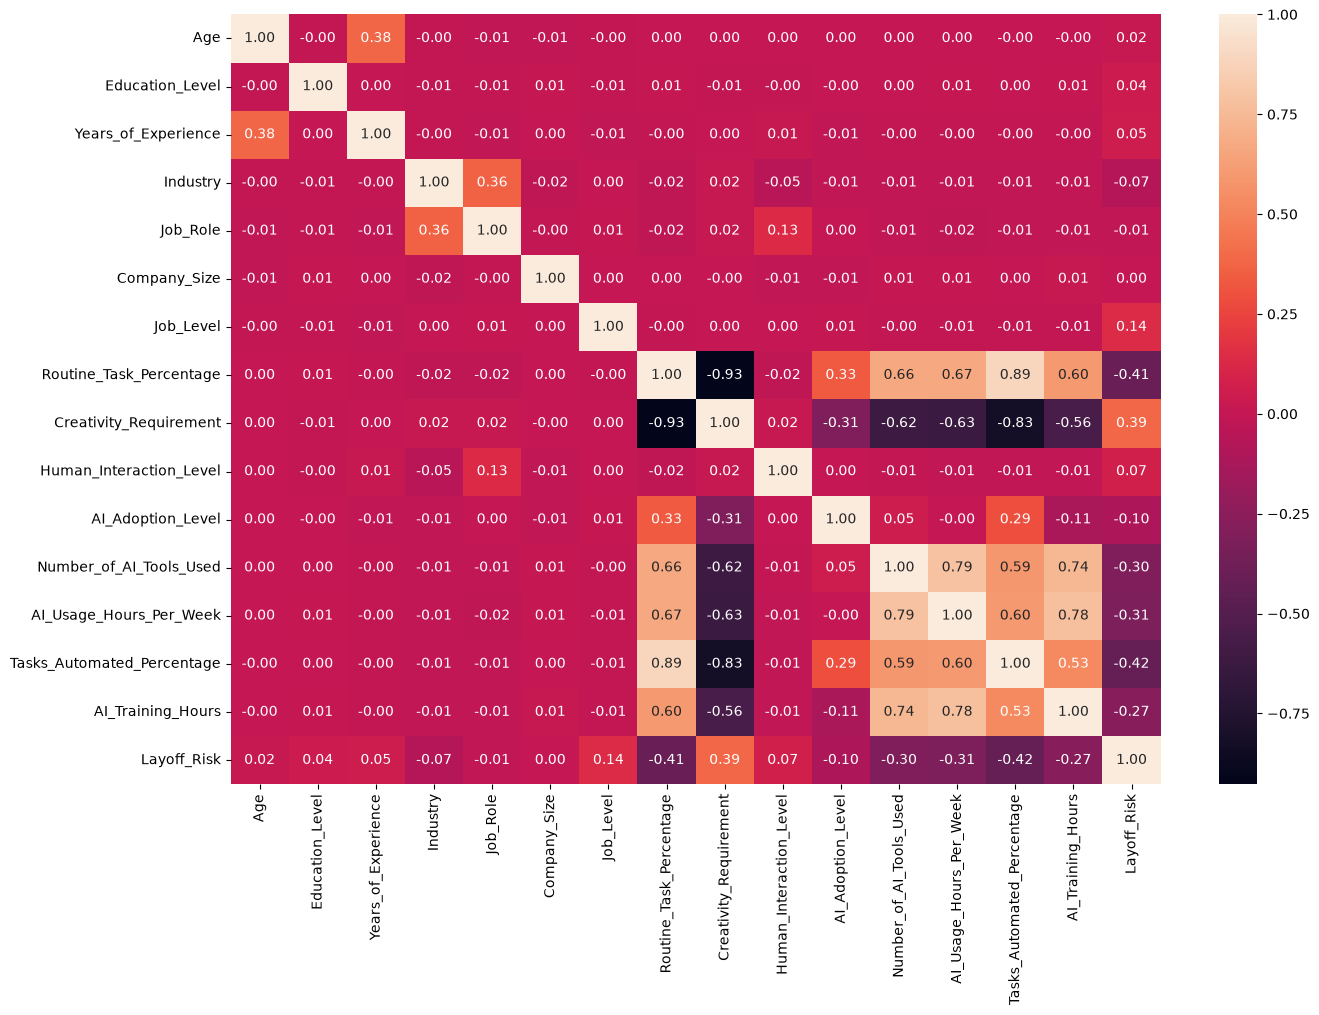

In [42]:
#let's check the correlation between each columns
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot=True,fmt=".2f")

we have high correlation between  "Routine_Task_Percentage" and "Tasks_Automated_Percentage" and target column some correlation with "Routine_Task_Percentage"

Text(0, 0.5, 'Tasks_Automated_Percentage')

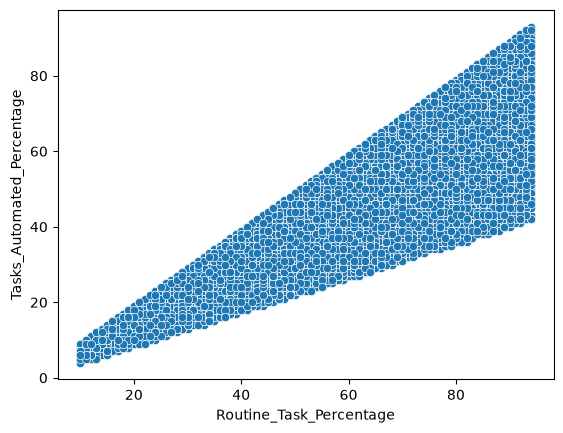

In [44]:
#now's lets visualize the correlation between them usinf scatter plot
sns.scatterplot(x=df["Routine_Task_Percentage"],y=df["Tasks_Automated_Percentage"])
plt.xlabel("Routine_Task_Percentage")
plt.ylabel("Tasks_Automated_Percentage")

Text(0.5, 0, 'Layoff_Risk')

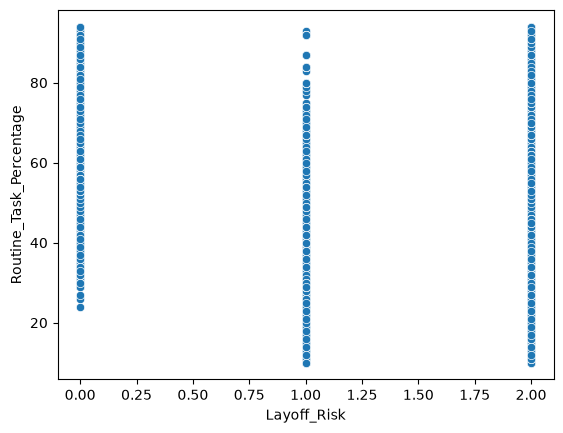

In [47]:
sns.scatterplot(y=df["Routine_Task_Percentage"],x=df["Layoff_Risk"])
plt.ylabel("Routine_Task_Percentage")
plt.xlabel("Layoff_Risk")

In [49]:
df["Layoff_Risk"].value_counts()

Layoff_Risk
0    6797
1    6602
2    6601
Name: count, dtype: int64

we could see the class is balanced

In [48]:
#separate x and y

x=df.drop("Layoff_Risk",axis=1)
y=df.Layoff_Risk

In [52]:
#train test split

x_train,x_test,y_train,y_test=train_test_split(x,y,stratify=y,random_state=42,test_size=0.2)

In [53]:
print("x train shape",x_train.shape)
print("x test shape",x_test.shape)
print("y train shape",y_train.shape)
print("y test shape",y_test.shape)

x train shape (16000, 15)
x test shape (4000, 15)
y train shape (16000,)
y test shape (4000,)


In [55]:
models={
    "logistic":LogisticRegression(),
    "svm":SVC(),
    "xgboost":XGBClassifier(),
    "KNN":KNeighborsClassifier(),
    "decision_tree":DecisionTreeClassifier(),
    "random_forest":RandomForestClassifier()
}

In [56]:
def model_selection(name,model):
    model.fit(x_train,y_train)
    train_pred=model.predict(x_train)
    test_pred=model.predict(x_test)
    print(name)
    print("Accuracy score of training",accuracy_score(y_train,train_pred))
    print("Accuracy score of testing",accuracy_score(y_test,test_pred))
    print("-"*30)
    print("\n")

In [57]:
for name,model in models.items():
    model_selection(name,Pipeline([("scaler",StandardScaler()),
              (name,model)]))

logistic
Accuracy score of training 0.83225
Accuracy score of testing 0.829
------------------------------


svm
Accuracy score of training 0.8865
Accuracy score of testing 0.86675
------------------------------


xgboost
Accuracy score of training 0.9999375
Accuracy score of testing 0.94925
------------------------------


KNN
Accuracy score of training 0.8854375
Accuracy score of testing 0.817
------------------------------


decision_tree
Accuracy score of training 1.0
Accuracy score of testing 0.8335
------------------------------


random_forest
Accuracy score of training 1.0
Accuracy score of testing 0.88925
------------------------------




xgboost is performing good , so lets do hyperparameter and find the best param and train it 

In [63]:
params={
    "objective":['binary:logistic', 'reg:squarederror', 'multi:softmax'],
    "eval_metric":['auc', 'logloss', 'rmse'],
    "booster":['gbtree',  'dart' ],
    "n_jobs":[100,200,300,400]
}

In [64]:
grid=GridSearchCV(estimator=XGBClassifier(),param_grid=params,verbose=2,cv=5)

In [65]:
grid.fit(x_train,y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV] END booster=gbtree, eval_metric=auc, n_jobs=100, objective=binary:logistic; total time=   0.4s
[CV] END booster=gbtree, eval_metric=auc, n_jobs=100, objective=binary:logistic; total time=   0.4s
[CV] END booster=gbtree, eval_metric=auc, n_jobs=100, objective=binary:logistic; total time=   0.3s
[CV] END booster=gbtree, eval_metric=auc, n_jobs=100, objective=binary:logistic; total time=   0.3s
[CV] END booster=gbtree, eval_metric=auc, n_jobs=100, objective=binary:logistic; total time=   0.3s
[CV] END booster=gbtree, eval_metric=auc, n_jobs=100, objective=reg:squarederror; total time=   0.3s
[CV] END booster=gbtree, eval_metric=auc, n_jobs=100, objective=reg:squarederror; total time=   0.3s
[CV] END booster=gbtree, eval_metric=auc, n_jobs=100, objective=reg:squarederror; total time=   0.3s
[CV] END booster=gbtree, eval_metric=auc, n_jobs=100, objective=reg:squarederror; total time=   0.3s
[CV] END booster=gbtree, eval_metr

c:\Users\swath\Desktop\Projects_MLDL\AI-Impact-on-Jobs-and-Layoff-Risk\AI-Impact-on-Jobs-and-Layoff-Risk-Prediction\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:55:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:341: `booster=dart` is deprecated. Use the tree booster directly with dropout parameters like `rate_drop`, `skip_drop`, or `one_drop`.
  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END booster=dart, eval_metric=auc, n_jobs=100, objective=binary:logistic; total time=   0.6s
[CV] END booster=dart, eval_metric=auc, n_jobs=100, objective=binary:logistic; total time=   0.6s
[CV] END booster=dart, eval_metric=auc, n_jobs=100, objective=binary:logistic; total time=   0.5s
[CV] END booster=dart, eval_metric=auc, n_jobs=100, objective=binary:logistic; total time=   0.5s
[CV] END booster=dart, eval_metric=auc, n_jobs=100, objective=binary:logistic; total time=   0.5s
[CV] END booster=dart, eval_metric=auc, n_jobs=100, objective=reg:squarederror; total time=   0.3s
[CV] END booster=dart, eval_metric=auc, n_jobs=100, objective=reg:squarederror; total time=   0.4s
[CV] END booster=dart, eval_metric=auc, n_jobs=100, objective=reg:squarederror; total time=   0.5s
[CV] END booster=dart, eval_metric=auc, n_jobs=100, objective=reg:squarederror; total time=   0.4s
[CV] END booster=dart, eval_metric=auc, n_jobs=100, objective=reg:squarederror; total time=   0.4s
[CV] END booste

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'booster': ['gbtree', 'dart'], 'eval_metric': ['auc', 'logloss', ...], 'n_jobs': [100, 200, ...], 'objective': ['binary:logistic', 'reg:squarederror', ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metriceva

In [66]:
print("Best params",grid.best_params_)
print("best score",grid.best_score_)

Best params {'booster': 'gbtree', 'eval_metric': 'auc', 'n_jobs': 100, 'objective': 'binary:logistic'}
best score 0.937


In [67]:
model=XGBClassifier(booster=grid.best_params_["booster"],eval_metric=grid.best_params_["eval_metric"],
                    n_jobs=grid.best_params_["n_jobs"],objective=grid.best_params_["objective"])

xgboost
Accuracy score of training 0.9999375
Accuracy score of testing 0.94925
------------------------------




In [77]:
def model_selection(name,model):
    model.fit(x_train,y_train)
    train_pred=model.predict(x_train)
    test_pred=model.predict(x_test)
    print(name)
    print("Accuracy score of training",accuracy_score(y_train,train_pred))
    print("Accuracy score of testing",accuracy_score(y_test,test_pred))
    print("\n")
    sns.heatmap(confusion_matrix(y_test,test_pred),annot=True,fmt=".2f")
    plt.xlabel("truth")
    plt.ylabel("predict")

xgboost
Accuracy score of training 0.9999375
Accuracy score of testing 0.94925




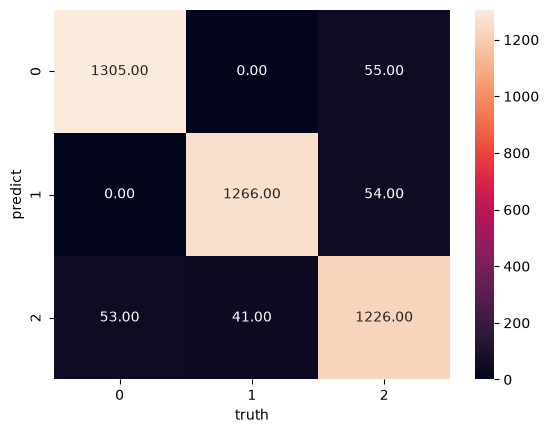

In [78]:
model_selection("xgboost",model)

In [43]:
df.columns

Index(['Age', 'Education_Level', 'Years_of_Experience', 'Industry', 'Job_Role',
       'Company_Size', 'Job_Level', 'Routine_Task_Percentage',
       'Creativity_Requirement', 'Human_Interaction_Level',
       'AI_Adoption_Level', 'Number_of_AI_Tools_Used',
       'AI_Usage_Hours_Per_Week', 'Tasks_Automated_Percentage',
       'AI_Training_Hours', 'Layoff_Risk'],
      dtype='str')